<a href="https://colab.research.google.com/github/Moquiuti/fundamentos-ia-investigando-algoritmos-abordagens-machine-learning/blob/main/aplicando_t%C3%A9cnicas_de_aprendizado_n%C3%A3o_supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Carregando o dataset Iris
iris = load_iris()

# Criando um DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [2]:
from sklearn.cluster import KMeans

# Selecionando apenas as features
X = iris.data

# Aplicando K-Means com 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Adicionando os clusters ao DataFrame
df['kmeans_cluster'] = kmeans_labels

print(df[['kmeans_cluster']].head())

   kmeans_cluster
0               1
1               1
2               1
3               1
4               1


In [3]:
from sklearn.cluster import AgglomerativeClustering

# Aplicando agrupamento hierárquico
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X)

# Adicionando os clusters ao DataFrame
df['hierarchical_cluster'] = hierarchical_labels

print(df[['hierarchical_cluster']].head())

   hierarchical_cluster
0                     1
1                     1
2                     1
3                     1
4                     1


In [4]:
from sklearn.decomposition import PCA

# Reduzindo para 2 dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Criando DataFrame com os componentes principais
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['kmeans_cluster'] = kmeans_labels
df_pca['hierarchical_cluster'] = hierarchical_labels
df_pca['target'] = iris.target

print(df_pca.head())

        PC1       PC2  kmeans_cluster  hierarchical_cluster  target
0 -2.684126  0.319397               1                     1       0
1 -2.714142 -0.177001               1                     1       0
2 -2.888991 -0.144949               1                     1       0
3 -2.745343 -0.318299               1                     1       0
4 -2.728717  0.326755               1                     1       0


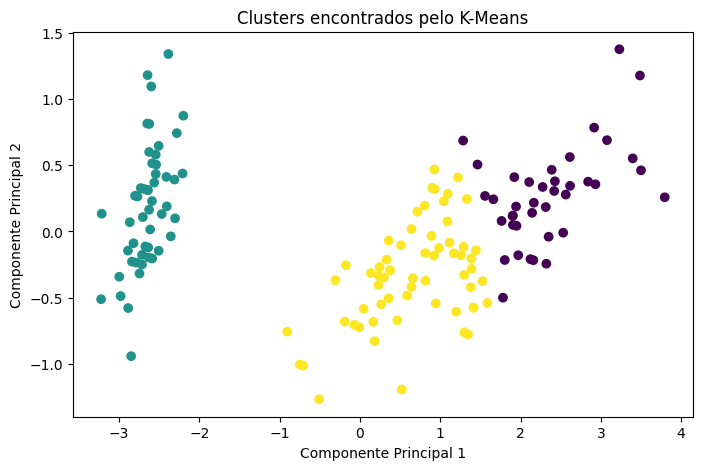

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['kmeans_cluster'])
plt.title('Clusters encontrados pelo K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

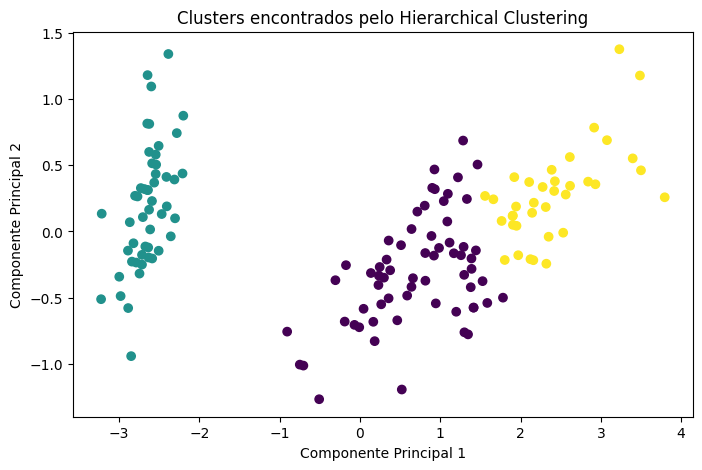

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['hierarchical_cluster'])
plt.title('Clusters encontrados pelo Hierarchical Clustering')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

Primeiras linhas do dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dados após PCA:
        PC1       PC2  kmeans_cluster  hierarchical_cluster  target
0 -2.684126  0.319397               1                     1       0
1 -2.714142 -0.177001               1                     1       0
2 -2.888991 -0.144949               1                     1       0
3 -2.745343 -0.318299               1                     1       0
4 -2.728717  0.326755               1                     1       0

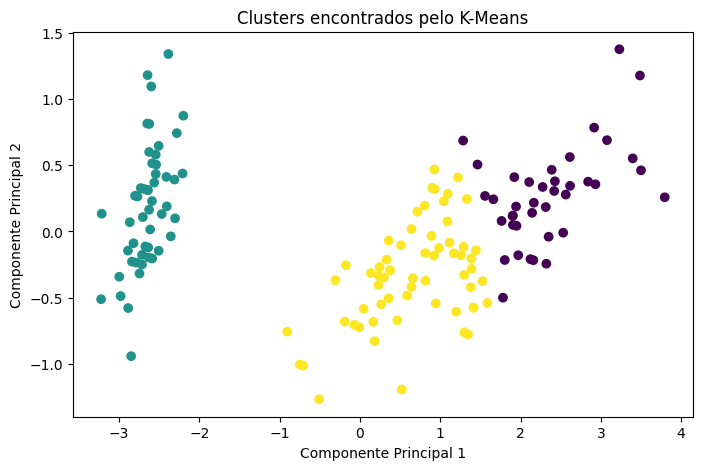

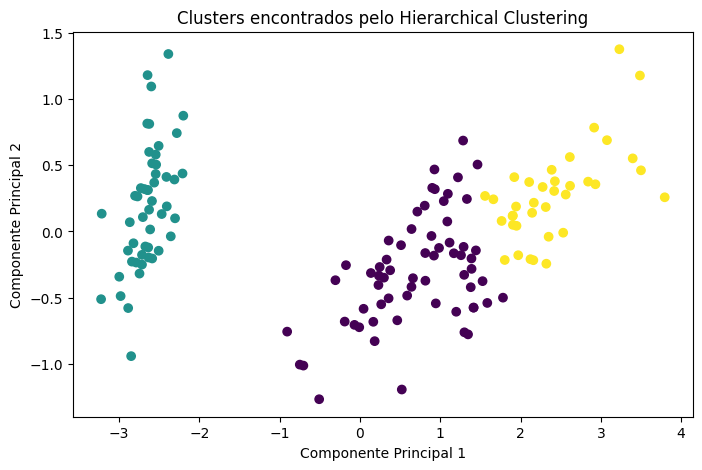

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# 1. Carregar dados
iris = load_iris()
X = iris.data

df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = iris.target

print("Primeiras linhas do dataset:")
print(df.head())

# 2. K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
df['kmeans_cluster'] = kmeans_labels

# 3. Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hierarchical_labels = hierarchical.fit_predict(X)
df['hierarchical_cluster'] = hierarchical_labels

# 4. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['kmeans_cluster'] = kmeans_labels
df_pca['hierarchical_cluster'] = hierarchical_labels
df_pca['target'] = iris.target

print("\nDados após PCA:")
print(df_pca.head())

# 5. Visualização K-Means
plt.figure(figsize=(8, 5))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['kmeans_cluster'])
plt.title('Clusters encontrados pelo K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# 6. Visualização Hierarchical Clustering
plt.figure(figsize=(8, 5))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['hierarchical_cluster'])
plt.title('Clusters encontrados pelo Hierarchical Clustering')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()